In [136]:
! pip3 install keras-tuner
! pip3 install tensorboard

In [202]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense,Dropout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import keras_tuner as kt



In [138]:
df=pd.read_csv('diabetes.csv')

In [139]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [141]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [142]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [143]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [144]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [145]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [146]:
model=Sequential()
model.add(Dense(32,activation='leaky_relu',input_dim=8))
model.add(Dense(16,activation='leaky_relu'))
model.add(Dense(1,activation='sigmoid'))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [147]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [148]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [149]:
callback=keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='auto',
    verbose=True
)



In [150]:
history=model.fit(X_train,Y_train,batch_size=32,validation_data=(X_test,Y_test),epochs=100,callbacks=callback)

Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3941 - loss: 0.7875 - val_accuracy: 0.5519 - val_loss: 0.6914
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6287 - loss: 0.6620 - val_accuracy: 0.7532 - val_loss: 0.5987
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7329 - loss: 0.5912 - val_accuracy: 0.8182 - val_loss: 0.5376
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7704 - loss: 0.5430 - val_accuracy: 0.8117 - val_loss: 0.5012
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7687 - loss: 0.5125 - val_accuracy: 0.8052 - val_loss: 0.4783
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7801 - loss: 0.4926 - val_accuracy: 0.7922 - val_loss: 0.4648
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7834 - loss: 0.4812 - val_accuracy: 0.7922 - val_loss: 0.4594
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4723 - val_accuracy: 0.8052 - val_loss: 0.4

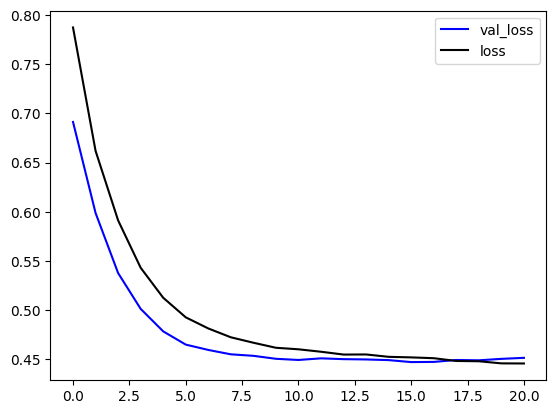

In [151]:
plt.plot(history.history['val_loss'],color='blue',label='val_loss')
plt.plot(history.history['loss'],color='black',label='loss')
plt.legend()
plt.show()

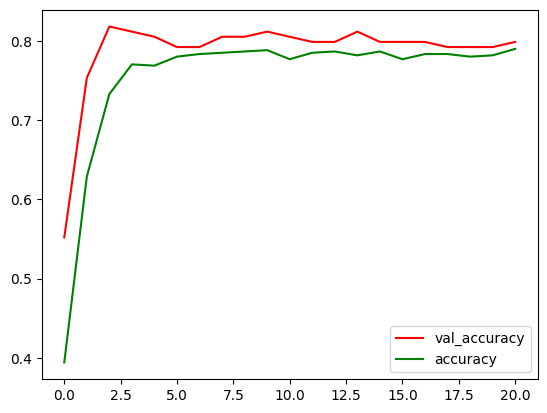

In [152]:
plt.plot(history.history['val_accuracy'],color='red',label='val_accuracy')
plt.plot(history.history['accuracy'],color='green',label='accuracy')
plt.legend(
)
plt.show()

### Implimenting the same with Keras-tuner tuning the hyperparametes and automating the workflow

#### Automatig the flow by just adjusting the values of optimizer by choosing the best one from it

In [153]:
def build_model(hp):
    model=Sequential()

    model.add(Dense(32,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))

    optimizer=hp.Choice('optimizer',values=['adam','sgd','adadelta','rmsprop',
                                          'nadam','adafactor'])
    
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

    return model


    

In [154]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=5)

Reloading Tuner from ./untitled_project/tuner0.json


In [155]:
tuner.search(X_train,Y_train,epochs=5,validation_data=(X_test,Y_test))

In [156]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [157]:
model=tuner.get_best_models(num_models=1)[0]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [158]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [159]:
# callback=keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#        patience=10,
#        mode='auto',
#        verbose=True

# )

In [160]:
history=model.fit(X_train,Y_train,epochs=200,validation_data=(X_test,Y_test),initial_epoch=6,batch_size=32)

Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7557 - loss: 0.5219 - val_accuracy: 0.8052 - val_loss: 0.5058
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7590 - loss: 0.5065 - val_accuracy: 0.7987 - val_loss: 0.4953
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7622 - loss: 0.4962 - val_accuracy: 0.8052 - val_loss: 0.4869
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7720 - loss: 0.4885 - val_accuracy: 0.7987 - val_loss: 0.4805
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7687 - loss: 0.4815 - val_accuracy: 0.7922 - val_loss: 0.4759
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7736 - loss: 0.4760 - val_accuracy: 0.7987 - val_loss: 0.4715
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7752 - loss: 0.4712 - val_accuracy: 0.7987 - val_loss: 0.4692
Epoch 14/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7736 - loss: 0.4673 - val_accuracy: 0.798

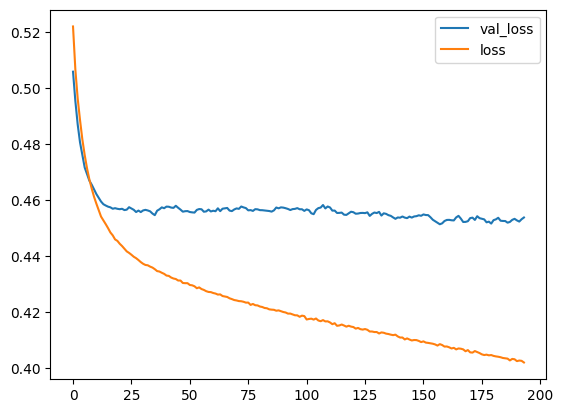

In [161]:
plt.plot(history.history['val_loss'],label='val_loss')
plt.plot(history.history['loss'],label='loss')
plt.legend()
plt.show()

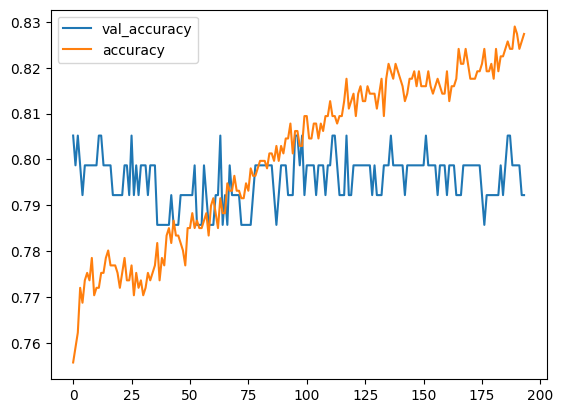

In [162]:
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['accuracy'],label='accuracy')
plt.legend()
plt.show()

#### Automatig the flow by just adjusting the no of nodes per layer of the neural network by choosing the best one from it

In [163]:
def build_model(hp):
    model=Sequential()
    
    units=hp.Int('units',min_value=32,max_value=128,step=16)

    model.add(Dense(units,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))    

    model.compile(optimizer='rmsprop',metrics=['accuracy'],loss='binary_crossentropy')

    return model


In [164]:
tuner=kt.RandomSearch(build_model,max_trials=5,objective='val_accuracy',directory='new_dir')

Reloading Tuner from new_dir/untitled_project/tuner0.json


In [165]:
tuner.search(X_train,Y_train,
             validation_data=(X_test,Y_test),
             epochs=10,verbose=True)

In [166]:
tuner.get_best_hyperparameters()[0].values

{'units': 112}

In [167]:
model_2=tuner.get_best_models(num_models=1)[0]

model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 112)            │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [168]:
hisotry=model_2.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=100,verbose=True,initial_epoch=6,batch_size=50)

Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7541 - loss: 0.5275 - val_accuracy: 0.8117 - val_loss: 0.5042
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7638 - loss: 0.4999 - val_accuracy: 0.7922 - val_loss: 0.4877
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4849 - val_accuracy: 0.7987 - val_loss: 0.4790
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7785 - loss: 0.4744 - val_accuracy: 0.7857 - val_loss: 0.4732
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4682 - val_accuracy: 0.7857 - val_loss: 0.4672
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7769 - loss: 0.4630 - val_accuracy: 0.7987 - val_loss: 0.4636
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7752 - loss: 0.4593 - val_accuracy: 0.7987 - val_loss: 0.4629
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7801 - loss: 0.4557 - val_accuracy: 0.79

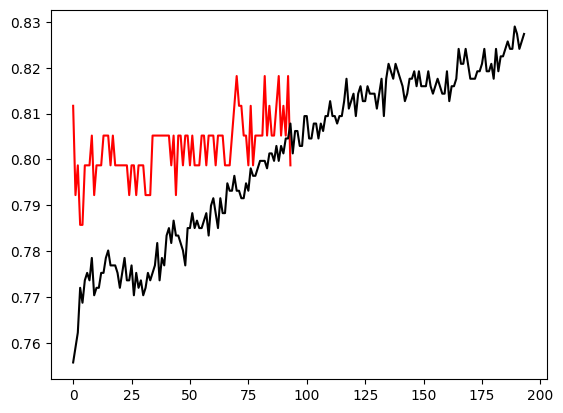

In [169]:
plt.plot(hisotry.history['val_accuracy'],color='red')
plt.plot(history.history['accuracy'],color='black')
plt.show()

In [215]:
def build_model(hp):
  #no of layers,no of nodes per layer,optimizer
  model=Sequential()

  counter=0

  for i in range(hp.Int('num_layers',min_value=1,max_value=10)):

    if counter==0:
      model.add(
          Dense(units=hp.Int('units'+str(i),min_value=32,max_value=512,step=32),
              activation=hp.Choice('activation'+str(i),values=['sigmoid','relu','tanh'])
              ,input_dim=8)
          )
      model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
    else:
      model.add(
          Dense(units=hp.Int('units'+str(i),min_value=32,max_value=512,step=32),
                      activation=hp.Choice('activation'+str(i),values=['sigmoid','relu','tanh'])
                      )
          )
               
      model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
  
    counter=counter+1
  
  model.add(Dense(1,activation='sigmoid'))

  model.compile(optimizer=hp.Choice('optimizer',
                values=['adam','sgd','adadelta','rmsprop','nadam','adafactor']),
                loss='binary_crossentropy',
                metrics=['accuracy'])
  
  return model
  

In [216]:
tuner=kt.RandomSearch(build_model,objective='val_accuracy',
                      max_trials=5,
                      directory='new_dir',
                      project_name='multiple_layers_5')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [218]:
tuner.search(X_train,Y_train,epochs=5,validation_data=(X_test,Y_test),verbose=True)

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.3571428656578064

Best val_accuracy So Far: 0.8181818127632141
Total elapsed time: 00h 00m 15s


In [219]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 4,
 'units0': 192,
 'activation0': 'tanh',
 'dropout0': 0.5,
 'optimizer': 'adam',
 'units1': 416,
 'activation1': 'relu',
 'dropout1': 0.6,
 'units2': 448,
 'activation2': 'relu',
 'dropout2': 0.6,
 'units3': 288,
 'activation3': 'sigmoid',
 'dropout3': 0.4,
 'units4': 32,
 'activation4': 'sigmoid',
 'dropout4': 0.7,
 'units5': 64,
 'activation5': 'relu',
 'dropout5': 0.4}

In [220]:
model_5=tuner.get_best_models(num_models=1)[0]
model_5.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 192)            │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 416)            │        80,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 416)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 448)            │       186,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 288)            │       129,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398,433 (1.52 MB)

 Trainable params: 398,433 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

In [222]:
history=model_5.fit(X_train,Y_train,epochs=100,validation_data=(X_test,Y_test),verbose=True,initial_epoch=6)

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8046 - loss: 0.4100 - val_accuracy: 0.8182 - val_loss: 0.4500
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7964 - loss: 0.4196 - val_accuracy: 0.8182 - val_loss: 0.4518
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8062 - loss: 0.4102 - val_accuracy: 0.8052 - val_loss: 0.4505
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7964 - loss: 0.4234 - val_accuracy: 0.8117 - val_loss: 0.4460
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8111 - loss: 0.4248 - val_accuracy: 0.7987 - val_loss: 0.4479
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7948 - loss: 0.4073 - val_accuracy: 0.8052 - val_loss: 0.4560
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8029 - loss: 0.4289 - val_accuracy: 0.7987 - val_loss: 0.4549
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8029 - loss: 0.4176 - val_accuracy: 0.

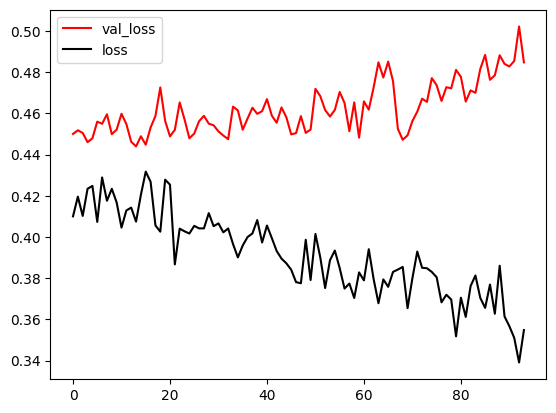

In [225]:
plt.plot(history.history['val_loss'],color='red',label='val_loss')
plt.plot(history.history['loss'],color='black',label='loss')
plt.legend()
plt.show()

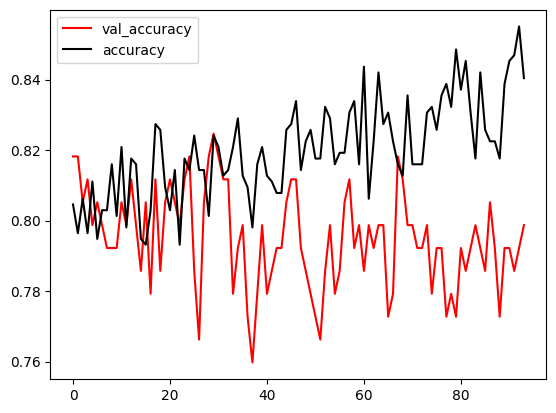

In [226]:
plt.plot(history.history['val_accuracy'],color='red',label='val_accuracy')
plt.plot(history.history['accuracy'],color='black',label='accuracy')
plt.legend()
plt.show()